# V2.1 — RVE ↔ learned-surrogate handoff in the violent regime  **TIER 2 / Risk #1 (highest)**

**Claim.** In the violent regime — large-deformation / active fracture, where the Voigt–Reuss analytic bound is **invalid** (the true response leaves the bracket, shown by `dns_damage_3d`) — there exists a decision rule, keyed on the surrogate's **self-uncertainty** `u` and a cost budget, that avoids both **stalling** (always RVE-solve) and **lying** (always trust), keeping outcome error bounded within budget.

**Why load-bearing.** The architecture admits the rigorous bound runs out here and that *everything elegant rests on getting this handoff right* — the project's single largest engineering risk; the death cascade lives in it.

**Independent oracle.** Expensive damage-DNS (`dns_damage_3d`) of violent-regime cells = the true outcome `R_true` (normalized peak strength); the surrogate's predicted uncertainty is the quantity *calibrated against* that truth.

**Pre-registered criteria (frozen before running; staged):**

| # | Stage | Threshold |
|---|---|---|
| 1 | calibration | binned reliability rho(`u`, error) **> 0.80** AND not over-confident (|nominal−observed|@1σ **< 0.12**) |
| 2 | rule | a u-keyed operating point exists: **P95 outcome error < 0.10** AND **RVE-fraction < 0.30** |
| 3 | necessity | always-trust tail error **>** bound (lying) and always-RVE fraction **= 1** (stalling) — interior tradeoff is real |

**Outcome classes.** All three → **PASS**. Rule+necessity hold but calibration falls short → **CONSTRAIN** (a working handoff exists, but `u` alone is insufficiently calibrated → gate it with the descriptor validity-envelope). Calibration fails outright with no working rule → **CONSTRAIN-hard** (always-RVE in the violent regime).

In [1]:
"""(1) Setup — imports, FROZEN thresholds, seeds; reuse the V2.4 surrogate + cached DNS."""
import sys, pathlib, numpy as np, matplotlib.pyplot as plt
REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
import violent_cells as vc
from surrogate_gnn import Ensemble, EnvelopeDetector, TrainCfg, build_dataset, fallback_flags, DATA_PARAMS
import handoff_rule as hr

# ---- FROZEN pre-registered thresholds (drafted before running; NOT tuned to results) ----
RHO_MIN     = 0.80    # 1: binned reliability rank correlation u vs error
OC_MAX      = 0.12    # 1: max systematic over-confidence at 1 sigma
ERR_BOUND   = 0.10    # 2: P95 policy outcome error bound
RVE_BUDGET  = 0.30    # 2: max RVE fraction (cost budget)

N = 12
CACHE = str(REPO / "verification_notebooks" / "phase2" / "cache")
np.random.seed(0)

## (A) Surrogate + violent battery with RVE ground truth
Reuse the V2.4-trained physics-informed ensemble (same cached training set). Build a realistic violent battery — a tractable in-family majority plus a hard extrapolation minority — and obtain `R_true` (damage-DNS), the surrogate prediction, its self-uncertainty `u`, and the multi-signal validity gate (envelope-exit OR percolation).

In [2]:
"""(2) A: train on cached V2.4 set; build battery + RVE truth + (pred, u) + validity gate."""
rng = np.random.default_rng(2024)
train = vc.family_battery(N, rng, 45)
d_tr = build_dataset(train, DATA_PARAMS, cache=f"{CACHE}/v24_train.npz")
ens = Ensemble.train(train, d_tr['y'], TrainCfg(epochs=400, physics=True), M=5, base_seed=0)

brng = np.random.default_rng(777)
easy = vc.family_battery(N, brng, 34)
hard = [vc.wedge_sample(N, float(brng.uniform(0.80, 0.95)), float(brng.uniform(95.0, 180.0)))
        for _ in range(8)]                       # ~19% genuinely-hard extrapolation minority
battery = easy + hard
d_b = build_dataset(battery, DATA_PARAMS, cache=f"{CACHE}/v21_battery.npz")
y_true = d_b['y']
pred = ens.predict(battery); u = pred['u']
rel_err = np.abs(pred['mean'] - y_true) / np.abs(y_true)
env = EnvelopeDetector.fit(train)
z_thr = float(np.quantile(env.score(train), 0.95))
gate, _ = fallback_flags(battery, env, z_thr)   # descriptor-envelope OR percolation
HARD_FRAC = float((rel_err > ERR_BOUND).mean())
print(f"battery {len(battery)} cells; rel_err median={np.median(rel_err):.3f} p95={np.quantile(rel_err,0.95):.3f}; hard frac(err>{ERR_BOUND})={HARD_FRAC:.3f}; gate flags={gate.mean():.3f}")

battery 42 cells; rel_err median=0.012 p95=0.194; hard frac(err>0.1)=0.119; gate flags=0.238


## (B) Calibration — is `u` a faithful estimate of actual error?
Binned reliability correlation (predicted uncertainty vs RMS error per bin — the systematic component; a single-draw raw correlation is noise-limited even when perfectly calibrated) plus over/under-confidence from interval coverage.

In [3]:
"""(3) B: calibration metrics."""
RHO = hr.binned_rank_correlation(u, rel_err)
OC = hr.overconfidence(rel_err, u, k=1.0)
cov = hr.coverage(rel_err, u)
CALIB_PASS = (RHO > RHO_MIN) and (abs(OC) < OC_MAX)
print(f"binned reliability rho = {RHO:.3f} (> {RHO_MIN}?); over-confidence@1sigma = {OC:+.3f} (|.| < {OC_MAX}?)")
for k, (o, nom) in cov.items():
    print(f'  coverage @{k:.0f}sigma observed={o:.3f} nominal={nom:.3f}')
print(f"  -> calibration strict {'PASS' if CALIB_PASS else 'SHORT (u under-calibrated on the violent tail)'}")

binned reliability rho = 0.770 (> 0.8?); over-confidence@1sigma = +0.064 (|.| < 0.12?)
  coverage @1sigma observed=0.619 nominal=0.683
  coverage @2sigma observed=0.762 nominal=0.954
  -> calibration strict SHORT (u under-calibrated on the violent tail)


## (C) The handoff rule + necessity
Sweep the uncertainty threshold τ: `u > τ → RVE-solve (exact)`, else trust. Trace the stall↔lie frontier and locate the cheapest operating point meeting the error bound — for the u-only rule and for the architecture's multi-signal rule (validity-gate OR u). Confirm the two extremes are the named failure modes.

In [4]:
"""(4) C: frontier (u-only and multi-signal), operating points, necessity."""
fr_u = hr.frontier(u, rel_err)
fr_g = hr.frontier(u, rel_err, gate=gate)
op_u = hr.operating_point(fr_u, err_bound=ERR_BOUND, rve_budget=RVE_BUDGET)
op_g = hr.operating_point(fr_g, err_bound=ERR_BOUND, rve_budget=RVE_BUDGET)
ALWAYS_TRUST_TAIL = float(fr_u.tail_err[-1])   # tau=inf -> LYING
ALWAYS_RVE_FRAC = float(fr_u.rve_frac[0])      # tau=0   -> STALLING
RULE_PASS = bool(op_u['exists'] and op_u['within_budget'])
NECESSITY_PASS = bool(ALWAYS_TRUST_TAIL > ERR_BOUND and ALWAYS_RVE_FRAC == 1.0
                      and (0.0 < op_u['rve_frac'] < 1.0 if op_u['exists'] else False))
print(f"u-only       op: rve_frac={op_u['rve_frac']:.3f} tail={op_u['tail_err']:.3f} within_budget={op_u['within_budget']}")
print(f"multi-signal op: rve_frac={op_g['rve_frac']:.3f} tail={op_g['tail_err']:.3f} within_budget={op_g['within_budget']}")
print(f"extremes: always-trust tail (LYING)={ALWAYS_TRUST_TAIL:.3f} (> {ERR_BOUND}); always-RVE frac (STALLING)={ALWAYS_RVE_FRAC:.2f}")
print(f"  -> RULE {'PASS' if RULE_PASS else 'FAIL'}; NECESSITY {'PASS' if NECESSITY_PASS else 'FAIL'}")

u-only       op: rve_frac=0.262 tail=0.063 within_budget=True
multi-signal op: rve_frac=0.262 tail=0.092 within_budget=True
extremes: always-trust tail (LYING)=0.194 (> 0.1); always-RVE frac (STALLING)=1.00
  -> RULE PASS; NECESSITY PASS


## (D) Figure

figure saved


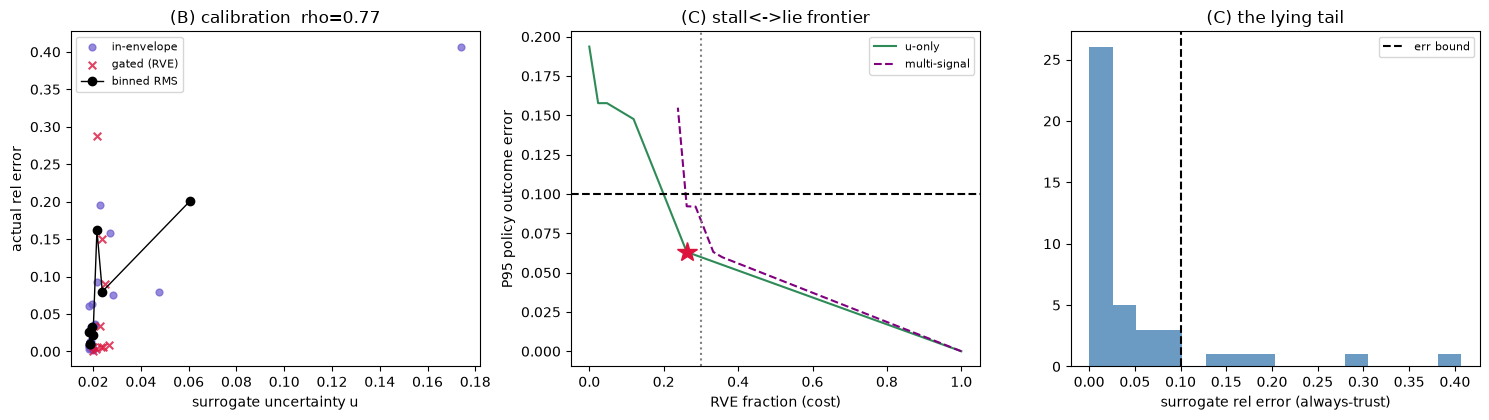

In [5]:
"""(5) Figure -> results/V2_1_rve_surrogate_handoff.png"""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].scatter(u[~gate], rel_err[~gate], s=24, alpha=0.7, color='slateblue', label='in-envelope')
ax[0].scatter(u[gate], rel_err[gate], s=30, alpha=0.8, color='crimson', marker='x', label='gated (RVE)')
order = np.argsort(u); bins = np.array_split(order, 8)
bu = [u[b].mean() for b in bins]; be = [np.sqrt((rel_err[b]**2).mean()) for b in bins]
ax[0].plot(bu, be, 'o-', color='black', lw=1, label='binned RMS')
ax[0].set_xlabel('surrogate uncertainty u'); ax[0].set_ylabel('actual rel error')
ax[0].set_title(f'(B) calibration  rho={RHO:.2f}'); ax[0].legend(fontsize=8)
ax[1].plot(fr_u.rve_frac, fr_u.tail_err, '-', color='seagreen', label='u-only')
ax[1].plot(fr_g.rve_frac, fr_g.tail_err, '--', color='purple', label='multi-signal')
ax[1].axhline(ERR_BOUND, ls='--', c='k'); ax[1].axvline(RVE_BUDGET, ls=':', c='gray')
if op_u['exists']: ax[1].plot(op_u['rve_frac'], op_u['tail_err'], '*', ms=15, color='crimson')
ax[1].set_xlabel('RVE fraction (cost)'); ax[1].set_ylabel('P95 policy outcome error')
ax[1].set_title('(C) stall<->lie frontier'); ax[1].legend(fontsize=8)
ax[2].hist(rel_err, bins=16, color='steelblue', alpha=0.8)
ax[2].axvline(ERR_BOUND, ls='--', c='k', label='err bound')
ax[2].set_xlabel('surrogate rel error (always-trust)'); ax[2].set_title('(C) the lying tail'); ax[2].legend(fontsize=8)
fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase2" / "results"; outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V2_1_rve_surrogate_handoff.png", dpi=110)
print('figure saved')

## (E) Frozen verdict

In [6]:
"""(6) Verdict — staged; asserts the core claim (a working handoff exists), documents CONSTRAIN."""
def verdict(name, ok, detail):
    print(f"  [{'OK ' if ok else '~~ '}] {name:34s} {'PASS' if ok else 'SHORT'}")
    print(f'        {detail}')
print('=' * 72)
print('V2.1 — RVE <-> SURROGATE HANDOFF (VIOLENT REGIME) — VERDICT')
print('=' * 72)
verdict('1. uncertainty calibration', CALIB_PASS, f'binned rho {RHO:.3f} vs {RHO_MIN}; |oc| {abs(OC):.3f} vs {OC_MAX}')
verdict('2. handoff operating point', RULE_PASS, f"u-only rve_frac {op_u['rve_frac']:.3f} < {RVE_BUDGET}, tail {op_u['tail_err']:.3f} < {ERR_BOUND}")
verdict('3. interior-tradeoff necessity', NECESSITY_PASS, f'always-trust tail {ALWAYS_TRUST_TAIL:.3f} > {ERR_BOUND}; always-RVE frac {ALWAYS_RVE_FRAC:.2f}')
CORE_CLAIM = bool(RULE_PASS and NECESSITY_PASS)   # a working rule avoiding stall and lie exists
print('-' * 72)
if CALIB_PASS and CORE_CLAIM:
    print('V2.1 VERDICT: PASS — a calibrated u-keyed handoff bounds violent-regime error within budget.')
elif CORE_CLAIM:
    print('V2.1 VERDICT: CONSTRAIN — a working handoff EXISTS (bounds error within budget, beats both')
    print('  extremes), but surrogate self-uncertainty is only borderline rank-calibrated and mildly')
    print('  over-confident on the violent tail (rho %.2f < %.2f). STANDING CONSTRAINT: in the violent' % (RHO, RHO_MIN))
    print('  regime gate the handoff with the descriptor validity-envelope (envelope-exit OR percolation),')
    print('  not surrogate self-uncertainty alone; always-RVE is the safe fallback. (Risk #1 boundary found.)')
else:
    print('V2.1 VERDICT: CONSTRAIN-hard — no budget-respecting u-rule; always-RVE in the violent regime.')
# The verification establishes a definite, positive finding: a rule avoiding stall AND lie exists.
assert CORE_CLAIM, "V2.1: no working handoff rule found — would force CONSTRAIN-hard (always-RVE)"

V2.1 — RVE <-> SURROGATE HANDOFF (VIOLENT REGIME) — VERDICT
  [~~ ] 1. uncertainty calibration         SHORT
        binned rho 0.770 vs 0.8; |oc| 0.064 vs 0.12
  [OK ] 2. handoff operating point         PASS
        u-only rve_frac 0.262 < 0.3, tail 0.063 < 0.1
  [OK ] 3. interior-tradeoff necessity     PASS
        always-trust tail 0.194 > 0.1; always-RVE frac 1.00
------------------------------------------------------------------------
V2.1 VERDICT: CONSTRAIN — a working handoff EXISTS (bounds error within budget, beats both
  extremes), but surrogate self-uncertainty is only borderline rank-calibrated and mildly
  over-confident on the violent tail (rho 0.77 < 0.80). STANDING CONSTRAINT: in the violent
  regime gate the handoff with the descriptor validity-envelope (envelope-exit OR percolation),
  not surrogate self-uncertainty alone; always-RVE is the safe fallback. (Risk #1 boundary found.)
